In [1]:
!pip install huggingface_hub

In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [23]:
import os
import random

import numpy as np
import torch
from peft import LoraConfig, TaskType, get_peft_model
from torch import nn


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


class ModelForSourceCodeEmbedding(nn.Module):
    def __init__(self, model_name, normalize=True):
        super(ModelForSourceCodeEmbedding, self).__init__()
        self.model = AutoModel.from_pretrained(model_name)
        self.normalize = normalize

    def forward(self, **kwargs):
        model_output = self.model(**kwargs)
        embeddings = self.average_pool(model_output, kwargs.get("attention_mask"))
        if self.normalize:
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings

    def average_pool(self, model_output, attention_mask):
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return (torch.sum(token_embeddings * input_mask_expanded, 1) /
                torch.clamp(input_mask_expanded.sum(1), min=1e-9))

    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.model, name)

In [24]:
from transformers import AutoModel, AutoTokenizer


model_name = "bigcode/starencoder"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = ModelForSourceCodeEmbedding(model_name)

In [25]:
model

ModelForSourceCodeEmbedding(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(49156, 768, padding_idx=49152)
      (position_embeddings): Embedding(1024, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [26]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=["key", "query", "value"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

In [27]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

In [28]:
torch.cuda.empty_cache()

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device);

In [30]:
def get_cosing(q1_embs, q2_embs):
    return torch.sum(q1_embs * q2_embs, axis=1)

def get_loss(cosine_score, labels):
    return torch.mean(torch.square(labels * (1 - cosine_score) + torch.clamp((1 - labels) * cosine_score, min=0.0)))

def threshold(x):
    return 1 if x > 0.5 else 0

In [31]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from tqdm import tqdm


train_cases = ["case-01", "case-02", "case-03", "case-04", "case-05"]
test_cases = ["case-06", "case-07"]

all_cases = ["case-01", "case-02", "case-03", "case-04", "case-05", "case-06", "case-07"]


def get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths):
    data = []

    for non_plagiarized_file_path in non_plagiarized_files_paths:
        data.append([original_file_path, non_plagiarized_file_path, 0])

    for plagiarized_file_path in plagiarized_files_paths:
        data.append([original_file_path, plagiarized_file_path, 1])

    df = pd.DataFrame(data, columns=["original_code_file", "secondary_code_file", "label"])
    
    return df

def get_paths(case, mode):
    original_file_path = os.path.join("plagiarism_dataset", case, "original", os.listdir(
        f"plagiarism_dataset/{case}/original")[0])

    # get all other cases' files:
    non_plagiarized_files_paths_all = []
    if mode == "train":
        for every_other_case in train_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths
    else:
        for every_other_case in all_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths

    # add your own case non-plagiarised files:
    non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "non-plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']
    non_plagiarized_files_paths_all += non_plagiarized_files_paths

    plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']

    return original_file_path, non_plagiarized_files_paths_all, plagiarized_files_paths

In [32]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-01", "train")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

In [33]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-06", "test")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

In [34]:
# train-test cycle:
EPOCHS = 30

epochs_losses_train = []
epochs_accuracies_train = []

epochs_losses_test = []
epochs_accuracies_test = []

for epoch in range(EPOCHS):
    train_total_loss = 0
    train_correct = 0
    
    test_total_loss = 0
    test_correct = 0
    
    # train:
    for case in train_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "train")
        train_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_train, y_train = train_df[["original_code_file", "secondary_code_file"]], train_df["label"]
    
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
        
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
    
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        loss = nn.CrossEntropyLoss()
        
        total_loss = 0
        correct = 0
        
        model.train()
        bar = tqdm(range(len(X_train)))
        for i in range(len(X_train)):
            original_code = open(X_train["original_code_file"][i], "r").read()
            secondary_code = open(X_train["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, return_tensors="pt", max_length=1024, truncation=True)
            q2 = tokenizer(secondary_code, return_tensors="pt", max_length=1024, truncation=True)
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_train[i]])
            label = label.to(device)
            
            optimizer.zero_grad()
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            loss_value.backward()
            optimizer.step()
        
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        train_total_loss += total_loss / len(X_train)
        train_correct += correct / len(X_train)

    # test:
    for case in test_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "test")
        test_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_test, y_test = test_df[["original_code_file", "secondary_code_file"]], test_df["label"]
    
        total_loss = 0
        correct = 0
        
        model.eval()
        bar = tqdm(range(len(X_test)))
        for i in range(len(X_test)):
            original_code = open(X_test["original_code_file"][i], "r").read()
            secondary_code = open(X_test["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, return_tensors="pt", max_length=1024, truncation=True)
            q2 = tokenizer(secondary_code, return_tensors="pt", max_length=1024, truncation=True)
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_test[i]])
            label = label.to(device)
            
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        test_total_loss += total_loss / len(X_test)
        test_correct += correct / len(X_test)
    
    epochs_losses_train.append(train_total_loss / 5)
    print(f"Epoch: {epoch}, Loss train: {train_total_loss / 5}")
    epochs_accuracies_train.append(train_correct / 5)
    print(f"Epoch: {epoch}, Accuracy train: {train_correct / 5}")
    
    epochs_losses_test.append(test_total_loss / 2)
    print(f"Epoch: {epoch}, Loss test: {test_total_loss / 2}")
    epochs_accuracies_test.append(test_correct / 2)
    print(f"Epoch: {epoch}, Accuracy test: {test_correct / 2}")

    # torch.save(model, f"models_graphcodebert/{epoch + 1}_emb_model.pth")

  0%|          | 0/584 [00:00<?, ?it/s]C:\Users\bred7\anaconda3\envs\vyatsu_environment\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
100%|██████████| 584/584 [01:00<00:00,  9.62it/s]

100%|██████████| 560/560 [01:31<00:00,  6.09it/s]

100%|██████████| 558/558 [01:09<00:00,  8.05it/s]

100%|██████████| 466/466 [00:30<00:00, 15.43it/s]

100%|██████████| 556/556 [01:04<00:00,  8.57it/s]

100%|██████████| 556/556 [00:57<00:00,  9.61it/s]

100%|██████████| 466/466 [00:26<00:00, 17.42it/s]

100%|██████████| 584/584 [01:00<00:00,  9.64it/s]

100%|██████████| 560/560 [01:31<00:00,  6.15it/s]

100%|██████████| 558/558 [01:02<00:00,  8.98it/s]

100%|██████████| 466/466 [00:29<00:00, 15.74it/s]

100%|██████████| 556/556 [01:04<00:00,  8.68it/s]

100%|██████████| 556/55

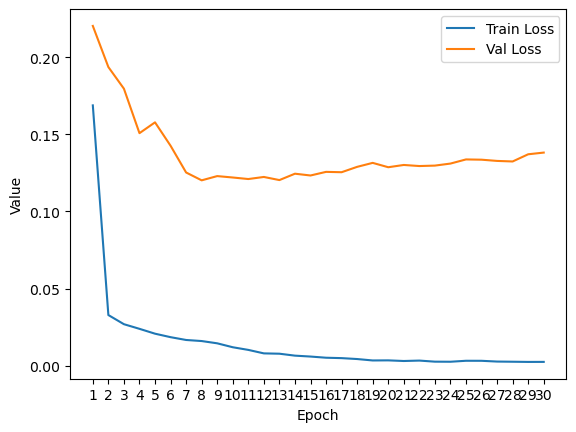

In [45]:
import matplotlib.pyplot as plt

EPOCHS = 30

plt.plot(range(1, EPOCHS + 1), epochs_losses_train, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), epochs_losses_test, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

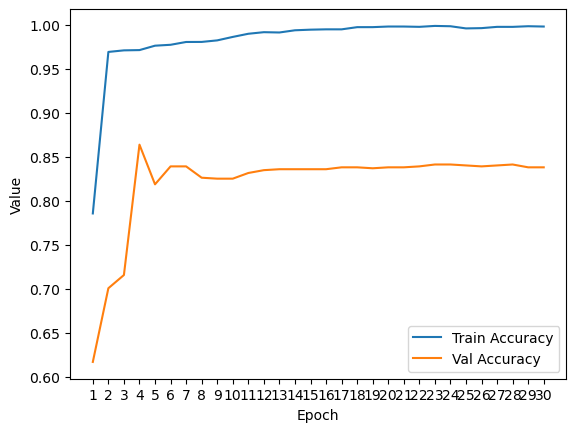

In [46]:
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_train, label="Train Accuracy")
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_test, label="Val Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

In [47]:
# torch.save(model, "models_codebert/code_embedding_model.pth")

In [48]:
# model = torch.load("code_embedding_model.pth")
# model.eval()

In [49]:
epochs_losses_test, len(epochs_losses_test)

([0.220322702375727,
  0.1936455195517764,
  0.17959988472051736,
  0.15075951791768377,
  0.15777880410790002,
  0.14260097983673958,
  0.12525525758031752,
  0.12016789965589905,
  0.12291659293165161,
  0.12200703088425993,
  0.12101057804846363,
  0.12235728598304732,
  0.12033421140218975,
  0.12446798317514819,
  0.12330928861826067,
  0.12566008693161726,
  0.12543001806444035,
  0.1289117774166071,
  0.13149268341183273,
  0.12866791907528224,
  0.13013713146058975,
  0.12943688394667854,
  0.12972181861699927,
  0.13104031323650497,
  0.13372911861478876,
  0.13355265479544592,
  0.13276124935325678,
  0.13240164617465686,
  0.13706979118039594,
  0.1381680115819255],
 30)

In [50]:
epochs_accuracies_test, len(epochs_accuracies_test)

([0.6169527896995708,
  0.7006437768240343,
  0.7156652360515021,
  0.8637339055793991,
  0.8186695278969958,
  0.8390557939914163,
  0.8390557939914163,
  0.8261802575107295,
  0.8251072961373391,
  0.8251072961373391,
  0.8315450643776825,
  0.8347639484978542,
  0.8358369098712446,
  0.8358369098712446,
  0.8358369098712446,
  0.8358369098712446,
  0.8379828326180258,
  0.8379828326180258,
  0.8369098712446352,
  0.8379828326180258,
  0.8379828326180258,
  0.8390557939914163,
  0.8412017167381974,
  0.8412017167381974,
  0.8401287553648069,
  0.8390557939914163,
  0.8401287553648069,
  0.8412017167381974,
  0.8379828326180258,
  0.8379828326180258],
 30)

In [51]:
print(f"Max accuracy: {max(epochs_accuracies_test)} at epoch {epochs_accuracies_test.index(max(epochs_accuracies_test)) + 1}")
print(f"Min loss: {min(epochs_losses_test)} at epoch {epochs_losses_test.index(min(epochs_losses_test)) + 1}")